# Task 2.1 - Dataset Selection and Setup

**Paper context:** ECTS is an early-classification method for time series. Our reproduction uses FordA as a public benchmark outside the paper's original seven-dataset set.

## Dataset Choice Justification

1. **Method match:** FordA is fixed-length time-series classification, directly compatible with prefix-based nearest-neighbor evaluation.
2. **Scale suitability:** 3601 training and 1320 test samples are sufficient for a meaningful CPU-only reproduction.
3. **Interpretability:** Binary labels make early-vs-full tradeoff easier to interpret.
4. **Protocol clarity:** We keep original length 500 and treat early views as prefixes (e.g., 100 points = 20%), not as a truncated replacement dataset.

## Limitations vs Original Paper

The original paper reports results across multiple UCR datasets and full ECTS cluster/support logic. Here we use one dataset (FordA) and simplified prefix-scan analysis, so conclusions are method-behavior evidence rather than full benchmark replication.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path('data')
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / 'FordA_TRAIN.tsv'
TEST_PATH = DATA_DIR / 'FordA_TEST.tsv'

train_df = pd.read_csv(TRAIN_PATH, sep='	', header=None)
test_df = pd.read_csv(TEST_PATH, sep='	', header=None)

X_train = train_df.iloc[:, 1:].to_numpy(dtype=float)
X_test = test_df.iloc[:, 1:].to_numpy(dtype=float)
y_train_raw = train_df.iloc[:, 0].to_numpy(dtype=int)
y_test_raw = test_df.iloc[:, 0].to_numpy(dtype=int)

# Map {-1, 1} to {0, 1} for sklearn convenience
y_train = (y_train_raw == 1).astype(int)
y_test = (y_test_raw == 1).astype(int)

print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')
print('Class labels in training set:', np.unique(y_train_raw))

Train shape: (3601, 500), Test shape: (1320, 500)
Class labels in training set: [-1  1]


**What this cell does:**
Loads FordA train/test TSV files, maps labels from `{-1, +1}` to `{0, 1}`, fixes random seed, and prints base shapes/labels.

**Why it matters for this paper:**
ECTS-style reproduction depends on consistent fixed-length series representation before any prefix slicing.


In [3]:
# Quick dataset summary table
summary = pd.DataFrame({
    'split': ['train', 'test'],
    'num_samples': [X_train.shape[0], X_test.shape[0]],
    'series_length': [X_train.shape[1], X_test.shape[1]],
})
summary

,split,num_samples,series_length
0,train,3601,500
1,test,1320,500


**What this cell does:**
Builds a compact dataset summary table (split size and sequence length).

**Why it matters:**
Confirms key setup assumptions used by all later tasks (especially prefix ratios over length 500).


             train_count  test_count
class_label                         
-1                  1846         681
 1                  1755         639


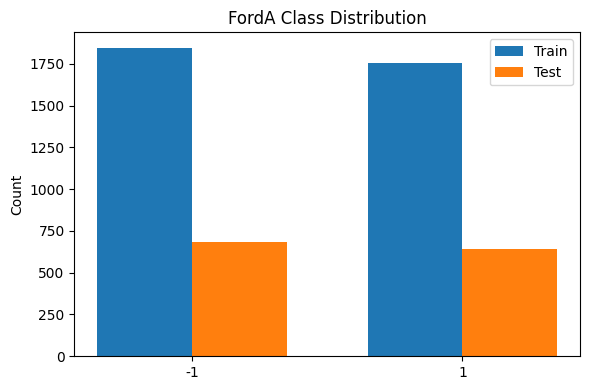

In [4]:
# Class distribution analysis
train_dist = pd.Series(y_train_raw).value_counts().sort_index()
test_dist = pd.Series(y_test_raw).value_counts().sort_index()

dist_df = pd.DataFrame({'train_count': train_dist, 'test_count': test_dist})
dist_df.index.name = 'class_label'
print(dist_df)

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(dist_df.index))
width = 0.35
ax.bar(x - width/2, dist_df['train_count'], width=width, label='Train')
ax.bar(x + width/2, dist_df['test_count'], width=width, label='Test')
ax.set_xticks(x)
ax.set_xticklabels(dist_df.index.astype(str))
ax.set_ylabel('Count')
ax.set_title('FordA Class Distribution')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'task_2_1_class_distribution.png', dpi=200)
plt.show()

**What this cell does:**
Computes class counts for train/test and saves a class-distribution bar chart to `results/task_2_1_class_distribution.png`.

**Why it matters:**
Class balance influences nearest-neighbor behavior and makes result interpretation more reliable.


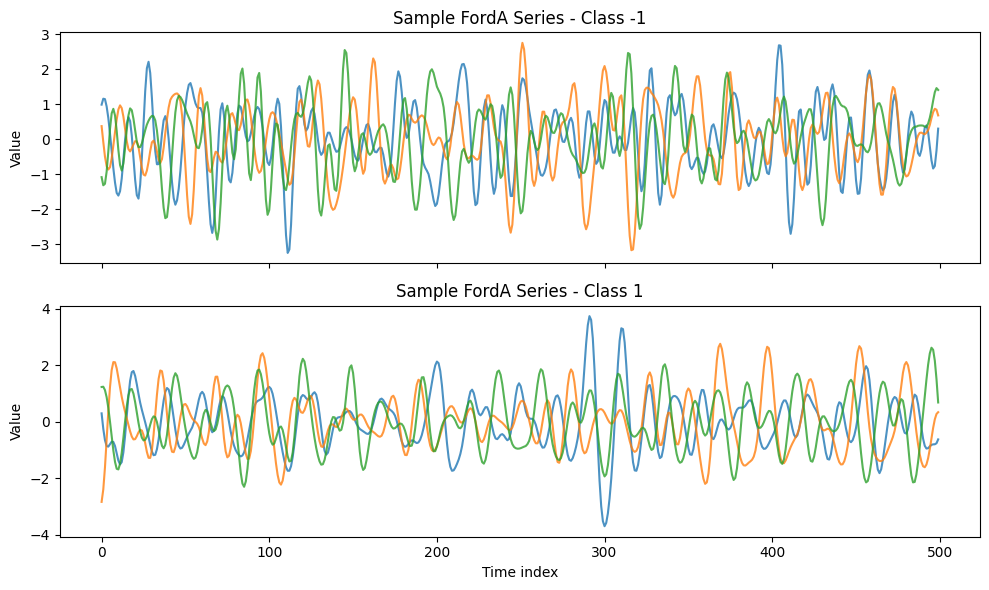

In [5]:
# Visualize sample time series from each class
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for ax, cls in zip(axes, [-1, 1]):
    idx = np.where(y_train_raw == cls)[0]
    chosen = rng.choice(idx, size=3, replace=False)
    for j in chosen:
        ax.plot(X_train[j], alpha=0.8)
    ax.set_title(f'Sample FordA Series - Class {cls}')
    ax.set_ylabel('Value')

axes[-1].set_xlabel('Time index')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'task_2_1_sample_series.png', dpi=200)
plt.show()

**What this cell does:**
Plots sample time series from each class and saves `results/task_2_1_sample_series.png`.

**Why it matters:**
Visually verifies that class-specific temporal patterns exist, supporting early-prefix experiments in Task 2.2.


## Task 2.1 Outcome

FordA satisfies the assignment constraints and provides a clear, reproducible basis for prefix-based early-classification analysis aligned with the selected paper's nearest-neighbor foundation.
